# **Analysis of BB84 protocol under the effect of different Side-Channel Attacks**

The BB84 protocol is a Quantum key distribution protocol that utalize quantum physiscs expecially polarization to distribute the secret key over unsecure channel.

Side-Channel attacks are a hardware level attacks that manipulate the QKD device of Alice or Bob to gather any information about the secret key.

In this colab we implement the **Intercept-Resend, Time-Shift, and the Detector Blinding attacks**. But because those attacks need hardware to be actually implemented, we modeled them using their correseponding QBER.

# **Importing Libraries**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# **Implementing the binary Entropy Function**

The Binary Entropy Function is used to theoretically calculate the amount of information that was leaked.

$H(q)=−qlog_2​(q)−(1−q)log_2​(1−q)$

**Also we need the binary entropy function to calculate the key rate.**

In [ ]:
def binary_entropy(q):
    q = np.clip(q, 1e-10, 1 - 1e-10)
    return -q * np.log2(q) - (1 - q) * np.log2(1 - q)

# **Implementing the Key Rate as a Function of QBER**

The Key Rate is how much of the recived key bits are similar to the sent bits. We can represnt the key rate function as below:

$R=(1−loss)×(1−2H(QBER))$

High key rate in BB84 means that Alice and Bob nearly chose the same basis to measure their qubits. It also can mean that there is no Eveasdropper in the middle of their communication. The existance of an Eve in the middle causes a lot of errors (causes high QBER), this high error damages the key bits causing the key rate to be low.

Therefore, theoretically:

*   High key rate= safe
*   Low key rate = unsafe




In [ ]:
def key_rate(qber, loss=0):
    return (1 - loss) * (1 - 2 * binary_entropy(qber))

# **Generate the QBER Values**

In [ ]:
qber_values = np.linspace(0, 0.2, 100)

# **Compute Key rate for the QBER values (No Attack)**

In [ ]:
baseline_rates = []

for q in qber_values:
    R = key_rate(q)
    baseline_rates.append(R)

# **Plot QBER vs. Key rate**

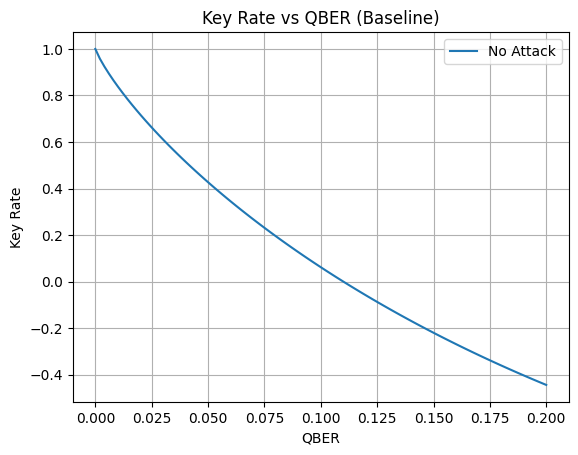

In [ ]:
plt.figure()
plt.plot(qber_values, baseline_rates, label="No Attack")
plt.xlabel("QBER")
plt.ylabel("Key Rate")
plt.title("Key Rate vs QBER (Baseline)")
plt.legend()
plt.grid()
plt.show()

The above graph describes the inverse relation between the Key Rate and the QBER.

**What we conclude from the above plot:**



*   The Key rate decreases as the QBER increase
*   when the QBER reaches a certain value (nearly 11), the Key rate will be nearly Zero



# **Model Side-Channel Attacks using their corresponding  QBER values**

In the below cell we assigned for each attack it's corresponding QBER, also a color and a label to visualize it better.

Note-- explain why each attack has that qber

In [ ]:
attacks = {
    "Intercept-Resend": {
        "qber": 0.20,
        "color": "green",
        "label": "Detected"
    },
    "Time-Shift": {
        "qber": 0.05,
        "color": "orange",
        "label": "Partially Hidden"
    },
    "Detector Blinding": {
        "qber": 0.001,
        "color": "red",
        "label": "Dangerous"
    }
}

# **Compute Key rate of each Attack**

In [ ]:
attack_rates = {}

attack_rates = {}

for attack, data in attacks.items():
    q = data["qber"]
    attack_rates[attack] = key_rate(q)

for attack, rate in attack_rates.items():
    print(f"{attack}: QBER={attacks[attack]}, Key Rate={rate:.4f}")

Intercept-Resend: QBER={'qber': 0.2, 'color': 'green', 'label': 'Detected'}, Key Rate=-0.4439
Time-Shift: QBER={'qber': 0.05, 'color': 'orange', 'label': 'Partially Hidden'}, Key Rate=0.4272
Detector Blinding: QBER={'qber': 0.001, 'color': 'red', 'label': 'Dangerous'}, Key Rate=0.9772


In the above cell we computed the Key rate for each attack from the key_rate function.

As you can see the Intercept-Resend attack has the lowest key rate which means the most damaged key bits. Meanwhile the Detector Blinding attack has the highest Key Rate which **theoretically** means that the system is **"safe"**

# **The BB84 Key Generation under different Side-Channel Attacks**

Assigned to each attack its corresponding QBER to model it.

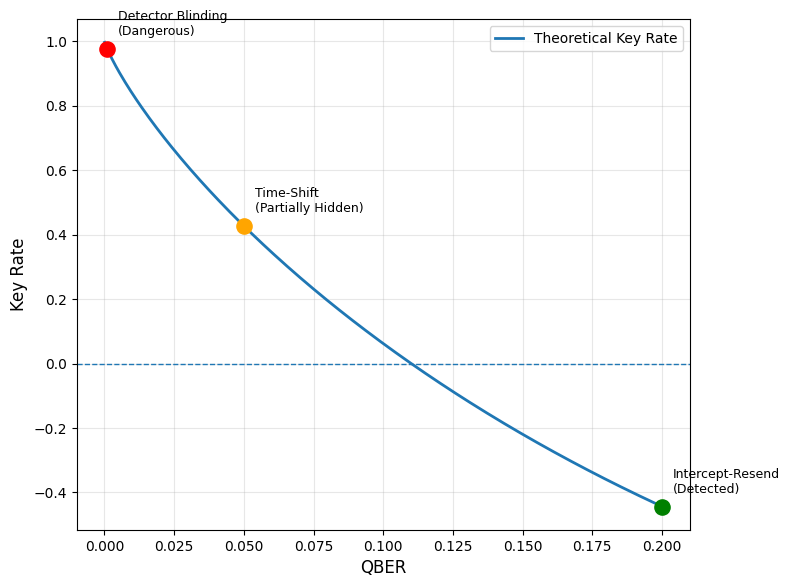

In [ ]:
qber = np.linspace(0.0001, 0.2, 300)
key_rates = key_rate(qber) #calculate the key rate for each attack(For each QBER value)
plt.figure(figsize=(8,6))

# Theoretical curve
plt.plot(qber, key_rates, linewidth=2, label="Theoretical Key Rate")

# Plot attack points
for name, data in attacks.items():
    q = data["qber"]
    R = key_rate(q)

    plt.scatter(q, R, color=data["color"], s=120, zorder=3)

    plt.annotate(
        f"{name}\n({data['label']})",
        (q, R),
        textcoords="offset points",
        xytext=(8,10),
        fontsize=9
    )

# Security threshold line
plt.axhline(0, linestyle='--', linewidth=1)

# Labels
plt.xlabel("QBER", fontsize=12)
plt.ylabel("Key Rate", fontsize=12)
plt.title("", fontsize=13)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

This graph shows how the key generation is affected under multiple attacks.

For the Intercept-Resend atttack (QBER=0.20) we can notice that the key rate went below zero which means that the key bits are totally damaged. Therefore Alice and Bob need to re-establish the BB84 connection.



# **The failure of QBER to detect some Side-Channel attacks**

/tmp/ipykernel_15307/823186816.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


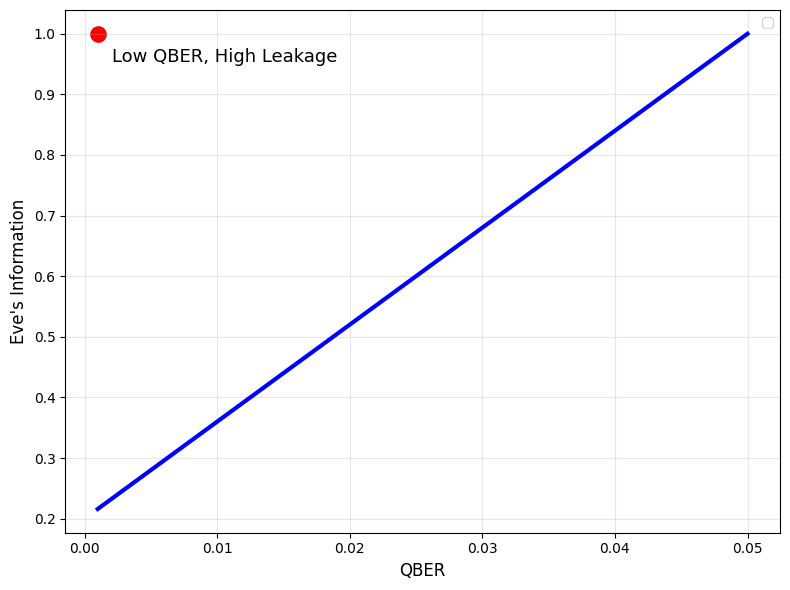

<Figure size 640x480 with 0 Axes>

In [ ]:
qber = np.linspace(0.001, 0.05, 200)
eve_info = 0.2 + 0.8 * (qber / 0.05)

# Plot
plt.figure(figsize=(8,6))

# Curve
plt.plot(qber, eve_info, linewidth=3, color='blue')

# Highlight extreme point
plt.scatter(0.001, 1.0, color='red', s=120)

plt.annotate(
    "Low QBER, High Leakage",
    (0.001, 1.0),
    xytext=(10,-20),
    textcoords='offset points',
    fontsize=13
)


plt.xlabel("QBER", fontsize=12)
plt.ylabel("Eve's Information", fontsize=12)
plt.title("", fontsize=13)


plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

The blue straight line introduces a naive assumption that low QBER implies low information leakage.

The red dot represents the detector blinding attack which invalidates that naive assumption.

The graph shows that the detector blinding attack violates that assumption. The Detector Blinding attack do not increase the QBER above the standered threshold which will cause neither Alice or Bob to notice that their connection is compormised.

What we finally conclude from that graph is the **QBER fails to detect** some side-channel attacks. Therefore **Hradware-Level monitoring mechanisms** are requird for those attacks.

# **Validation Using qkdpy library to simulate BB84**

**Step 1: Generate theoritical curve**

In [ ]:
theoretical_rates = [key_rate(q) for q in qber_values]

**Step 2: Generate simuation data**

In [ ]:
from qkdpy import BB84, QuantumChannel

sim_qber = []
sim_rates = []

for noise in [0.01, 0.03, 0.05, 0.08, 0.1]:
    channel = QuantumChannel(
        misalignment_error=noise,
        noise_level=noise,
        noise_model='depolarizing'
    )
    bb84 = BB84(channel=channel, key_length=1000)
    result = bb84.execute()

    q = result['qber']
    R = key_rate(q)

    sim_qber.append(q)
    sim_rates.append(R)


BB84 Estimated QBER: 0.0057306590257879654
BB84 Estimated QBER: 0.013201320132013201
BB84 Estimated QBER: 0.01913265306122449
BB84 Estimated QBER: 0.04126719466444352
BB84 Estimated QBER: 0.04582441113490364


**Step 3: Plot both Theoritical and Simulation**

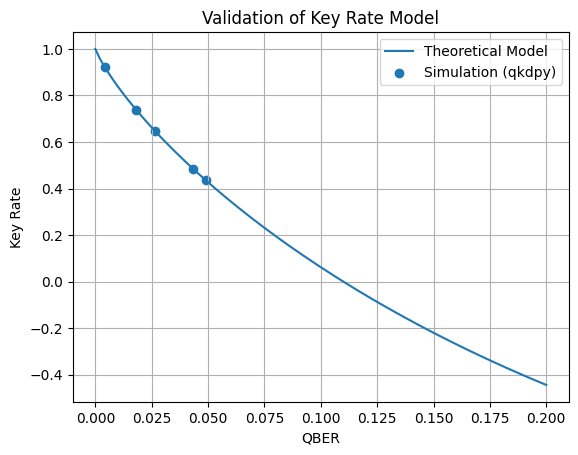

In [ ]:
plt.figure()

# Theoretical curve
plt.plot(qber_values, theoretical_rates, label="Theoretical Model")

# Simulation points
plt.scatter(sim_qber, sim_rates, label="Simulation (qkdpy)")

plt.xlabel("QBER")
plt.ylabel("Key Rate")
plt.title("Validation of Key Rate Model")
plt.legend()
plt.grid()

plt.show()

**Importing libraries**

##**Now about the mathematical and statistical limitations**



#**Here we find the optimal amount of noise preprocessing (in simulated caes of different values of qber)**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

**Basic Mathematical Functions and Entropy Definitions** - Contains the core Shannon binary entropy calculator

In [ ]:
def binary_entropy(x):
    x = np.clip(x, 1e-10, 1-10e-10)
    return -x * np.log2(x) - (1 - x) * np.log2(1 - x)

 **Main Simulation Function for Key Rate Analysis** - Encapsulates the entire BB84 noisy preprocessing logic

In [ ]:
def simulate_key_rate_with_logic():

    #
    # **Physical Channel Parameters and Initial Setup** - Defines baseline QBER, error correction efficiency, and noise range
    #
    intrinsic_qber = 0.11
    ec_efficiency = 1.15

    added_noise = np.linspace(0, 0.25, 100)

    key_rates = []
    eve_info_list = []
    ec_cost_list = []

    #
    # **Iterative Key Rate Calculation Loop** - Evaluates the impact of varying artificial noise on Bob's cost and Eve's information
    #
    for epsilon in added_noise:
        total_qber = intrinsic_qber + epsilon - 2 * intrinsic_qber * epsilon
        ec_cost = ec_efficiency * binary_entropy(total_qber)
        eve_info = binary_entropy(intrinsic_qber) * np.exp(-15 * epsilon)

        rate = 1 - ec_cost - eve_info
        rate = max(0, rate)

        key_rates.append(rate)
        eve_info_list.append(eve_info)
        ec_cost_list.append(ec_cost)

    #
    # **Optimal Point Identification and Extraction** - Finds the exact noise value that maximizes the secure key rate
    #
    max_rate_idx = np.argmax(key_rates)
    opt_noise = added_noise[max_rate_idx]
    max_rate = key_rates[max_rate_idx]

    #
    # **Plot Generation and Visual Representation** - Configures matplotlib to graph the simulation results and highlight the optimum
    #
    plt.figure(figsize=(12, 7))
    plt.plot(added_noise * 100, key_rates, label='Secure Key Rate', color='green', lw=3)
    plt.fill_between(added_noise * 100, 0, key_rates, color='green', alpha=0.1)

    plt.axvspan(0, opt_noise*100*0.5, color='red', alpha=0.1, label='Noise too low (Eve knows too much)')
    plt.axvspan(opt_noise*100*1.5, 25, color='orange', alpha=0.1, label='Noise too high (EC cost too high)')
    plt.scatter([opt_noise * 100], [max_rate], color='black', zorder=5)
    plt.annotate(f'OPTIMAL POINT\n(Noise: {opt_noise*100:.1f}%)',
                 xy=(opt_noise*100, max_rate), xytext=(opt_noise*100 + 2, max_rate + 0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05))

    plt.title('Effect of Noisy Preprocessing on BB84 Security', fontsize=14)
    plt.xlabel('Artificial Noise Added by Alice (%)', fontsize=12)
    plt.ylabel('Key Rate (bits per pulse)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.ylim(0, max(key_rates) + 0.2)
    plt.show()

**Execution of the Simulation Script** - Triggers the main function to run the logic and display the plots

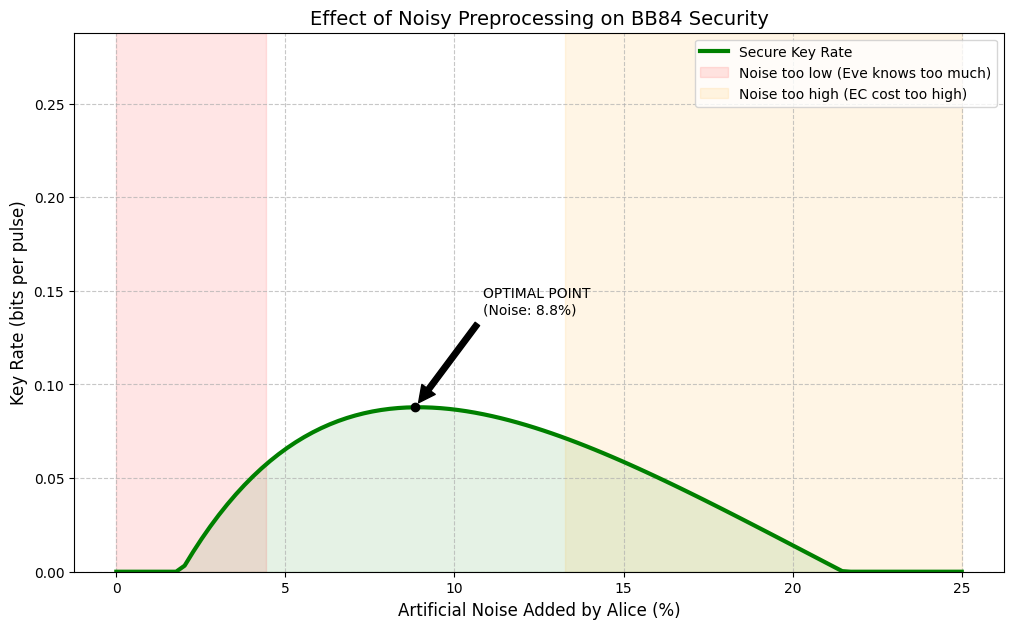

In [ ]:
simulate_key_rate_with_logic()

#**And now we put in perspective the key rate when using artificial noise and when following the classical implementation**

Importing libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

 **Binary Entropy Calculation Function** - Computes the Shannon entropy to evaluate information limits

In [ ]:
def binary_entropy(x):
    x = np.clip(x, 1e-10, 1-10e-10)
    return -x * np.log2(x) - (1 - x) * np.log2(1 - x)

**Alice's Noise Optimization Algorithm** - Determines the optimal artificial noise to maximize secure key rate

In [ ]:
def optimize_noise(natural_qber):
    ec_efficiency = 1.15
    possible_noises = np.linspace(0, 0.15, 200)

    best_rate = 0
    optimal_noise = 0

    for epsilon in possible_noises:
        total_qber = natural_qber + epsilon - 2 * natural_qber * epsilon

        if total_qber > 0.15:
            continue

        ec_cost = ec_efficiency * binary_entropy(total_qber)
        eve_info = binary_entropy(natural_qber) * np.exp(-15 * epsilon)
        rate = 1 - ec_cost - eve_info

        if rate > best_rate:
            best_rate = rate
            optimal_noise = epsilon

    standard_ec_cost = ec_efficiency * binary_entropy(natural_qber)
    standard_eve_info = binary_entropy(natural_qber)
    standard_rate = max(0, 1 - standard_ec_cost - standard_eve_info)

    return optimal_noise, best_rate, standard_rate

**Monte Carlo Simulation Execution** - Runs multiple iterations generating random natural QBER values

In [ ]:
num_simulations = 1000
natural_qbers = np.random.uniform(0.02, 0.10, num_simulations)

optimal_noises_applied = []
optimized_key_rates = []
standard_key_rates = []

for q_nat in natural_qbers:
    opt_noise, opt_rate, std_rate = optimize_noise(q_nat)
    optimal_noises_applied.append(opt_noise)
    optimized_key_rates.append(opt_rate)
    standard_key_rates.append(std_rate)

**Data Sorting and Array Structuring** - Organizes the simulated results for smooth continuous line plotting

In [ ]:
sorted_indices = np.argsort(natural_qbers)
natural_qbers_sorted = natural_qbers[sorted_indices]
optimal_noises_sorted = np.array(optimal_noises_applied)[sorted_indices]
optimized_rates_sorted = np.array(optimized_key_rates)[sorted_indices]
standard_rates_sorted = np.array(standard_key_rates)[sorted_indices]

**Graphical Visualization of Results** - Generates the side-by-side comparative plots for the simulation

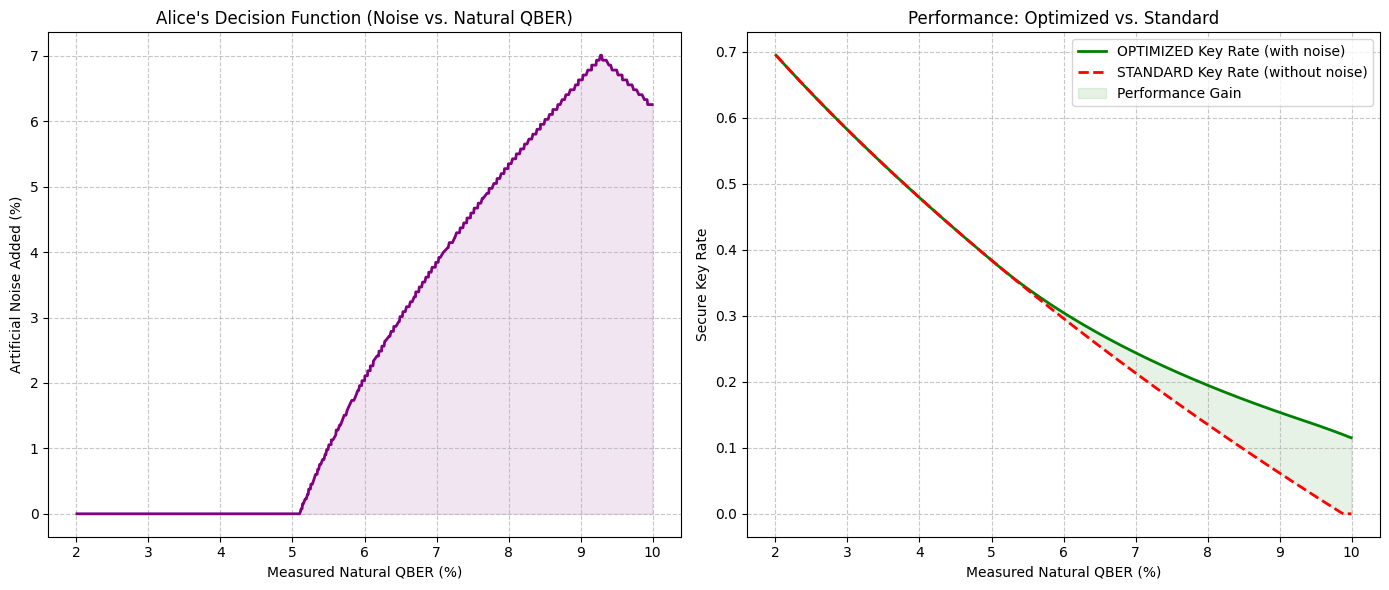

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(natural_qbers_sorted * 100, optimal_noises_sorted * 100, color='purple', lw=2)
plt.fill_between(natural_qbers_sorted * 100, 0, optimal_noises_sorted * 100, color='purple', alpha=0.1)
plt.title('Alice\'s Decision Function (Noise vs. Natural QBER)')
plt.xlabel('Measured Natural QBER (%)')
plt.ylabel('Artificial Noise Added (%)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(natural_qbers_sorted * 100, optimized_rates_sorted, label='OPTIMIZED Key Rate (with noise)', color='green', lw=2)
plt.plot(natural_qbers_sorted * 100, standard_rates_sorted, label='STANDARD Key Rate (without noise)', color='red', linestyle='dashed', lw=2)
plt.fill_between(natural_qbers_sorted * 100, standard_rates_sorted, optimized_rates_sorted, color='green', alpha=0.1, label='Performance Gain')
plt.title('Performance: Optimized vs. Standard')
plt.xlabel('Measured Natural QBER (%)')
plt.ylabel('Secure Key Rate')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()